In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import re
import joblib
from collections import Counter
from urllib.parse import urlparse
from scipy.stats import entropy as scipy_entropy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df1 = pd.read_csv("data/phishing1.csv")[['url','label']]

df2 = pd.read_csv("data/phishing2.csv")
df2 = df2[df2['label'].isin([0,2])]
df2['label'] = df2['label'].replace({2:1})
df2 = df2[['url','label']]

print("Dataset 1:", df1.shape)
print("Dataset 2:", df2.shape)

Dataset 1: (48812, 2)
Dataset 2: (522142, 2)


In [4]:
def fast_entropy(s):
    if len(s) == 0:
        return 0
    counts = Counter(s)
    probs = np.array(list(counts.values())) / len(s)
    return scipy_entropy(probs)

In [5]:
def extract_features(urls):
    df = pd.DataFrame()

    df['url_length'] = urls.str.len()
    df['has_https'] = urls.str.startswith("https").astype(int)
    df['dot_count'] = urls.str.count(r'\.')
    df['subdomain_count'] = urls.str.extract(r'https?://([^/]+)')[0].str.count(r'\.')
    df['has_ip'] = urls.str.contains(r'\d+\.\d+\.\d+\.\d+', regex=True).astype(int)
    df['special_char_count'] = urls.str.count(r'[^\w]')
    df['digit_count'] = urls.str.count(r'\d')
    df['digit_ratio'] = df['digit_count'] / df['url_length']
    df['param_count'] = urls.str.count(r'\?') + urls.str.count(r'&')
    df['brand_keyword'] = urls.str.contains(
        r'paypal|google|facebook|amazon|bank|apple|microsoft|netflix',
        case=False, regex=True).astype(int)
    df['suspicious_tld'] = urls.str.extract(r'\.([a-zA-Z0-9]+)$')[0].isin(
        ['xyz','top','gq','tk','ml','ga','cf','pw']).astype(int)
    df['url_entropy'] = urls.apply(fast_entropy)
    df['domain_entropy'] = urls.str.extract(r'https?://([^/]+)')[0].fillna('').apply(
        lambda x: fast_entropy(x) if len(x) > 0 else 0)

    # NEW ADVANCED FEATURES
    df['hyphen_count'] = urls.str.count(r'-')
    df['path_depth'] = urls.str.count(r'/')
    df['token_count'] = urls.str.count(r'[.\-_/]')
    df['vowel_ratio'] = urls.str.count(r'[aeiouAEIOU]') / df['url_length']
    df['domain_length'] = urls.str.extract(r'https?://([^/]+)')[0].fillna('').str.len()
    df['phish_keyword'] = urls.str.contains(
        r'login|secure|verify|account|update|signin|confirm|banking|password',
        case=False, regex=True).astype(int)
    df['at_symbol'] = urls.str.contains(r'@', regex=False).astype(int)
    df['double_slash'] = urls.str.count(r'//')

    return df

In [6]:
print("Extracting features for Dataset 1...")
features_df1 = extract_features(df1['url'])
features_df1['label'] = df1['label'].values

print("Extracting features for Dataset 2...")
features_df2 = extract_features(df2['url'])
features_df2['label'] = df2['label'].values

print("Dataset 1 features shape:", features_df1.shape)
print("Dataset 2 features shape:", features_df2.shape)

Extracting features for Dataset 1...
Extracting features for Dataset 2...
Dataset 1 features shape: (48812, 22)
Dataset 2 features shape: (522142, 22)


In [7]:
X = features_df1.drop('label', axis=1)
y = features_df1['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_external = features_df2.drop('label', axis=1)
y_external = features_df2['label']

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("External:", X_external.shape)

Train: (39049, 21)
Test: (9763, 21)
External: (522142, 21)


In [8]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', scale_pos_weight=3),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
}

results = {}

for name, m in models.items():
    print(f"Training {name}...")
    m.fit(X_train, y_train)
    
    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)[:,1]
    
    results[name] = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4)
    }
    print(f"  Done. F1: {results[name]['F1']}  ROC-AUC: {results[name]['ROC-AUC']}")

print("\nAll models trained.")

Training Random Forest...
  Done. F1: 0.9997  ROC-AUC: 0.9997
Training XGBoost...
  Done. F1: 0.9997  ROC-AUC: 0.9997
Training Gradient Boosting...
  Done. F1: 0.9996  ROC-AUC: 0.9999
Training Logistic Regression...
  Done. F1: 0.9997  ROC-AUC: 0.9998

All models trained.


In [9]:
results_df = pd.DataFrame(results).T
print(results_df.to_string())

                     Accuracy  Precision  Recall      F1  ROC-AUC
Random Forest          0.9997     1.0000  0.9994  0.9997   0.9997
XGBoost                0.9997     1.0000  0.9994  0.9997   0.9997
Gradient Boosting      0.9996     0.9998  0.9994  0.9996   0.9999
Logistic Regression    0.9997     1.0000  0.9994  0.9997   0.9998


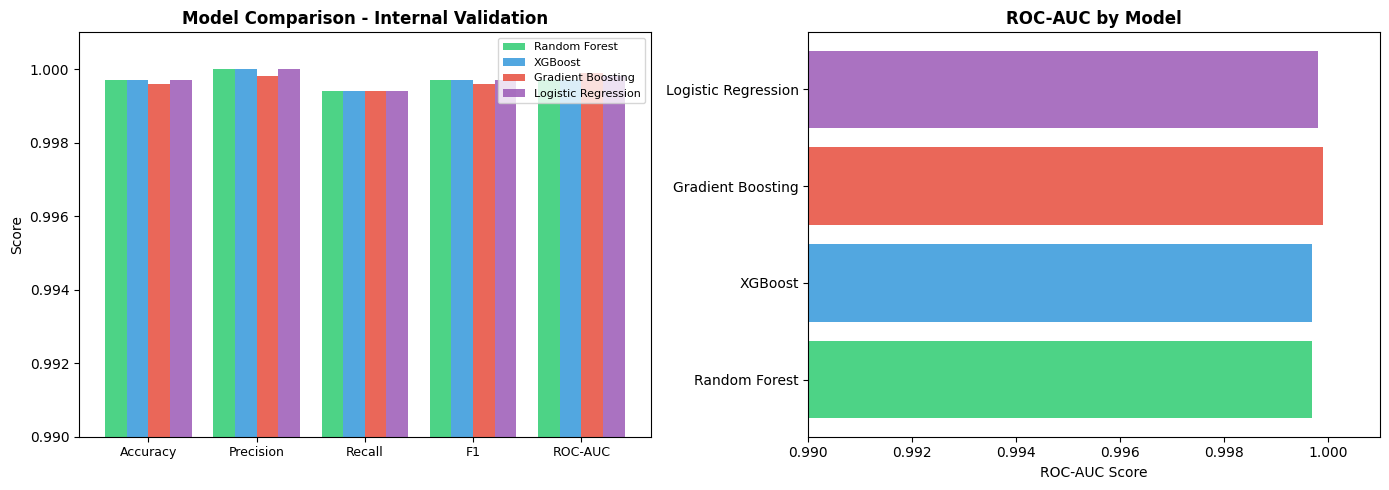

Chart saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for i, (name, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i*width, row[metrics], width, label=name, color=colors[i], alpha=0.85)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics, fontsize=9)
axes[0].set_ylim(0.99, 1.001)
axes[0].set_title('Model Comparison - Internal Validation', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_ylabel('Score')

# ROC-AUC bar
axes[1].barh(list(results_df.index), results_df['ROC-AUC'], color=colors, alpha=0.85)
axes[1].set_xlim(0.99, 1.001)
axes[1].set_title('ROC-AUC by Model', fontweight='bold')
axes[1].set_xlabel('ROC-AUC Score')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

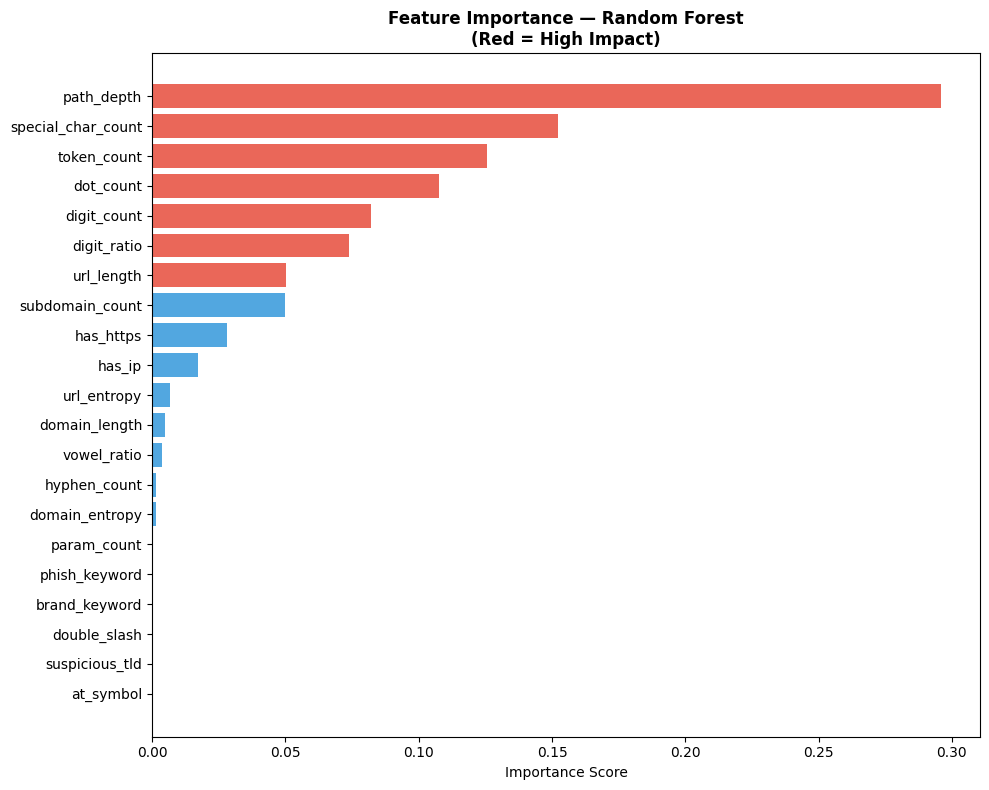

Chart saved.


In [11]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors_imp = ['#e74c3c' if x > 0.05 else '#3498db' for x in imp_df['Importance']]
plt.barh(imp_df['Feature'], imp_df['Importance'], color=colors_imp, alpha=0.85)
plt.title('Feature Importance — Random Forest\n(Red = High Impact)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [12]:
best_model = models["Gradient Boosting"]
joblib.dump(best_model, "best_model.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")
print("Best model saved: Gradient Boosting (ROC-AUC: 0.9999)")

Best model saved: Gradient Boosting (ROC-AUC: 0.9999)
